In [ ]:
# Import necessary packages
from folddof import to_rottrans, to_backbone, to_bb_mode
from folddof.io import get_coords_with_mask, savebb2pdb, merge_pdb
from folddof.utils import opt_root_mean_square_deviation
from folddof.frame import PeptideUnitFrame
import pymanopt
import gemmi
import torch
import numpy as np
import matplotlib.pyplot as plt
import py2Dmol


# Define the cost function to be optimized
def cost_func(isomers, label_bb_coords):
    manifold = pymanopt.manifolds.SpecialOrthogonalGroup(3, k=isomers.shape[0]+1)
    @pymanopt.function.pytorch(manifold)
    def cost_rmsd(opt_rotations):
        opt_bb_coords = to_backbone(opt_rotations[None], isomers[None], mode=to_bb_mode.Pep_GlobalRots_IsoRots).squeeze(0).flatten(0, 1)
        rmsd = opt_root_mean_square_deviation(opt_bb_coords, label_bb_coords)
        return rmsd
    return manifold, cost_rmsd

In [2]:
# Load the PDB structure and convert it into local frames
pdb_id, asym_id = "1C7S", "A"
st = gemmi.read_structure(f'/home/zzf/data/pdb_archive/mmcif/{pdb_id}.cif.gz')
st.remove_alternative_conformations()
chain = st[0].get_subchain(asym_id)
three_letter_seq = [res.name for res in chain]
label_bb_coords, _ = get_coords_with_mask(chain, atoms=['N', 'CA', 'C', 'O'], numres_first=False, dtype=torch.float64)
# label_bb_coords.shape: ([N CA C O] atoms, length, 3)
rotmats, trans, isomers, _, _ = to_rottrans(label_bb_coords)
avg_isomers = PeptideUnitFrame.to_avg_loc_ca_ia1_wrt_n_ia1(isomers)

In [3]:
avg_bb_coords = to_backbone(
    rotmats[None], 
    avg_isomers[None],
    mode=to_bb_mode.Pep_GlobalRots_IsoRots,
    ).squeeze(0)

In [4]:
opt_root_mean_square_deviation(avg_bb_coords.flatten(0, 1), label_bb_coords.transpose(0, 1).flatten(0, 1))

tensor(3.5631, dtype=torch.float64)

In [ ]:
# Start the optimization
initial_point = rotmats
problem = pymanopt.Problem(*cost_func(avg_isomers, label_bb_coords.transpose(0, 1).flatten(0, 1))) # three_letter_seq, pdb_id, asym_id, '_avg'
optimizer = pymanopt.optimizers.ConjugateGradient("PolakRibiere", max_iterations=20000 if initial_point is None else 3, verbosity=0, log_verbosity=1)
result = optimizer.run(problem, initial_point=initial_point.numpy())
# opt_bb_coords = to_backbone(torch.from_numpy(result.point[None]), avg_isomers[None], mode=to_bb_mode.Pep_GlobalRots_IsoRots)

In [6]:
iter_points = torch.from_numpy(np.stack(result.log['iterations']['point'], axis=0))
iter_bb_coords = to_backbone(iter_points, avg_isomers[None], mode=to_bb_mode.Pep_GlobalRots_IsoRots)

In [7]:
# opt_root_mean_square_deviation(iter_bb_coords.flatten(1,2), label_bb_coords.transpose(0, 1).flatten(0, 1).unsqueeze(0))

In [8]:
for idx, _bb_coords in enumerate(iter_bb_coords):
    savebb2pdb(three_letter_seq, _bb_coords, output_path=f"./pymanopt_cache/{pdb_id}.{asym_id}.pymanopt.bb.{idx}.pdb")

merge_pdb(*[f"./pymanopt_cache/{pdb_id}.{asym_id}.pymanopt.bb.{idx}.pdb" for idx in range(iter_bb_coords.shape[0])], 
          output_path=f"./pymanopt_cache/{pdb_id}.{asym_id}.pymanopt.bb.pdb",
          unlink=True,
          )

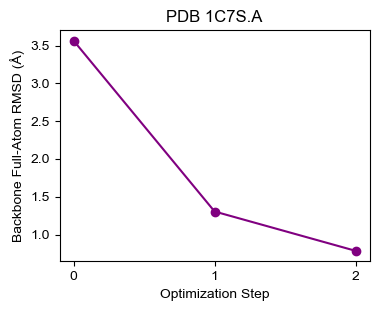

In [9]:
plt.figure(figsize=(4,3))
ax = plt.plot(range(len(result.log['iterations']['cost'])), np.array(result.log['iterations']['cost']), color='purple', marker='o')
plt.title(f"PDB {pdb_id}.{asym_id}") # (Start From Label Peptide Rotations)
plt.ylabel("Backbone Full-Atom RMSD (Å)")
plt.xlabel("Optimization Step")
plt.xticks([0, 1, 2])
#plt.ylim(0, None)
plt.show()

In [10]:
# Start the optimization from uniform noise on SO(3)
initial_point = None
problem = pymanopt.Problem(*cost_func(avg_isomers, label_bb_coords.transpose(0, 1).flatten(0, 1)))
optimizer = pymanopt.optimizers.ConjugateGradient("PolakRibiere", max_iterations=20000 if initial_point is None else 4, verbosity=0, log_verbosity=1)
result = optimizer.run(problem, initial_point=initial_point)
#opt_bb_coords = to_backbone(torch.from_numpy(result.point[None]), avg_isomers[None], mode=to_bb_mode.Pep_GlobalRots_IsoRots)

In [11]:
CHUNKSIZE = 500
iter_points = torch.from_numpy(np.stack(result.log['iterations']['point'][::CHUNKSIZE], axis=0))
iter_bb_coords = to_backbone(iter_points, avg_isomers[None], mode=to_bb_mode.Pep_GlobalRots_IsoRots)

In [12]:
for idx, _bb_coords in enumerate(iter_bb_coords):
    savebb2pdb(three_letter_seq, _bb_coords, output_path=f"./pymanopt_cache/{pdb_id}.{asym_id}.pymanopt.bb.noise_opt.{idx}.pdb")

merge_pdb(*[f"./pymanopt_cache/{pdb_id}.{asym_id}.pymanopt.bb.noise_opt.{idx}.pdb" for idx in range(iter_bb_coords.shape[0])], 
          output_path=f"./pymanopt_cache/{pdb_id}.{asym_id}.pymanopt.bb.noise_opt.pdb", 
          unlink=True)

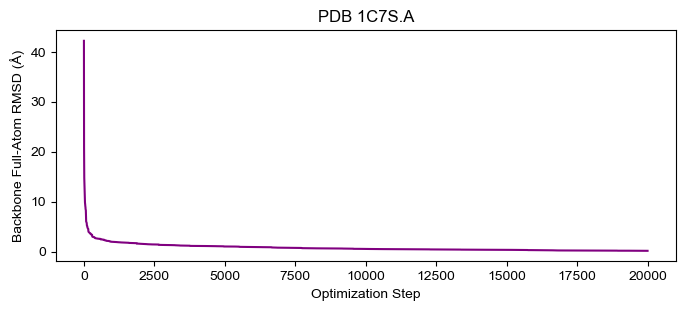

In [13]:
plt.figure(figsize=(8,3))
ax = plt.plot(range(len(result.log['iterations']['cost'])), np.array(result.log['iterations']['cost']), color='purple')
#plt.yscale('log')
#plt.xscale('log')
#plt.ylim(0, None)
plt.title(f"PDB {pdb_id}.{asym_id}")
plt.ylabel("Backbone Full-Atom RMSD (Å)")
plt.xlabel("Optimization Step")
plt.show()

In [14]:
viewer = py2Dmol.view(size=(600, 600), width=1)
viewer.add_pdb(f"./pymanopt_cache/{pdb_id}.{asym_id}.pymanopt.bb.noise_opt.pdb", chains=['A'])
viewer.show()